---
# PsPM-style trimming preview

In [74]:
%reload_ext autoreload
%autoreload 2

In [75]:
import numpy as np
import pandas as pd
from pathlib import Path

from calinet.data import (
    pspm_trim,
    _find_task_events_file,
    run_pspm_trim_directory
)

from calinet.core.io import (
    read_physio_tsv_headerless,
    infer_json_sidecar,
    load_json
)

from calinet.plotting import _generate_single_qa_plot

from lazyfmri import plotting

from calinet.logger import init_logging
init_logging()

import logging
logger = logging.getLogger(__name__)

In [ ]:
# history | any window is applied to the already-trimmed time series following calinet.config.trim_window (default = [-10, 30])
# because I used -10 for most of the participants again, this means the start of the time series was unchanged; 
# only the end of the time series was.

re_trimmed = {
    "amsterdam": [
        {
            "subject": "sub-CalinetAmsterdam19",
            "task": "acquisition",
            "window": [-10, 20]
        }
    ],
    "austin": [
        {
            "subject": "sub-CalinetAustin21",
            "task": "acquisition",
            "window": [-10, 15]
        },
        {
            "subject": "sub-CalinetAustin22",
            "task": "acquisition",
            "window": [-10, 15]
        },
        {
            "subject": "sub-CalinetAustin23",
            "task": "acquisition",
            "window": [-10, 20]
        },
        {
            "subject": "sub-CalinetAustin24",
            "task": "acquisition",
            "window": [-10, 20]
        },                       
    ],
    "london": [
        {
            "subject": "sub-CalinetLondon01",
            "task": "extinction",
            "window": [-10, 20]
        },
        {
            "subject": "sub-CalinetLondon31",
            "task": "extinction",
            "window": [-10, 20]
        }        
    ],
    "stockholm": [
        {
            "subject": "sub-CalinetStockholm05",
            "task": "extinction",
            "window": [-10, 15]
        },
        {
            "subject": "sub-CalinetStockholm23",
            "task": "extinction",
            "window": [-10, 20]
        }        
    ]
}

In [115]:
base_path = Path(r'Z:/CALINET2/converted')
site        = 'Stockholm'
id          = '23'
task        = ['acquisition', 'extinction'][1]
sub_id      = f'sub-Calinet{site.capitalize()}{id}'
sub_path    = base_path / site / sub_id / 'physio'

print(sub_path)

Z:\CALINET2\converted\Stockholm\sub-CalinetStockholm23\physio


In [116]:
phys_path = list(sub_path.glob(f'*task-{task}*scr_*.tsv.gz'))[0]
print(phys_path)

json_path = infer_json_sidecar(phys_path)
print(json_path)
sr = load_json(json_path).get("SamplingFrequency")
print(f"SamplingFrequency = {sr}")

task_path = _find_task_events_file(phys_path)
print(task_path)

physio_df = read_physio_tsv_headerless(phys_path)
events_df = pd.read_csv(task_path, delimiter='\t')

print(physio_df.shape, events_df.shape)

Z:\CALINET2\converted\Stockholm\sub-CalinetStockholm23\physio\sub-CalinetStockholm23_task-extinction_recording-scr_physio.tsv.gz
Z:\CALINET2\converted\Stockholm\sub-CalinetStockholm23\physio\sub-CalinetStockholm23_task-extinction_recording-scr_physio.json
SamplingFrequency = 2000.0
Z:\CALINET2\converted\Stockholm\sub-CalinetStockholm23\physio\sub-CalinetStockholm23_task-extinction_events.tsv
(2079491, 2) (80, 6)


In [117]:
%matplotlib inline
trim_window =  [-10, 20]

[2026-04-21 12:39:51.308] [sub-CalinetStockholm05] [INFO] calinet.data - Starting PsPM-style trimming
[2026-04-21 12:39:51.318] [sub-CalinetStockholm05] [INFO] calinet.data - Trimming parameters: from=-10, to=20, reference=marker
[2026-04-21 12:39:51.335] [sub-CalinetStockholm05] [INFO] calinet.data - StartTime=0.000s, subtracting this from onset times to align channels
[2026-04-21 12:39:51.337] [sub-CalinetStockholm05] [INFO] calinet.data - Start=0.000s (first onset=10.000s, offset=-10.000s), end=1037.466s (last onset=1017.466s, offset=20.000s)
[2026-04-21 12:39:51.548] [sub-CalinetStockholm05] [INFO] calinet.data - Trimming complete


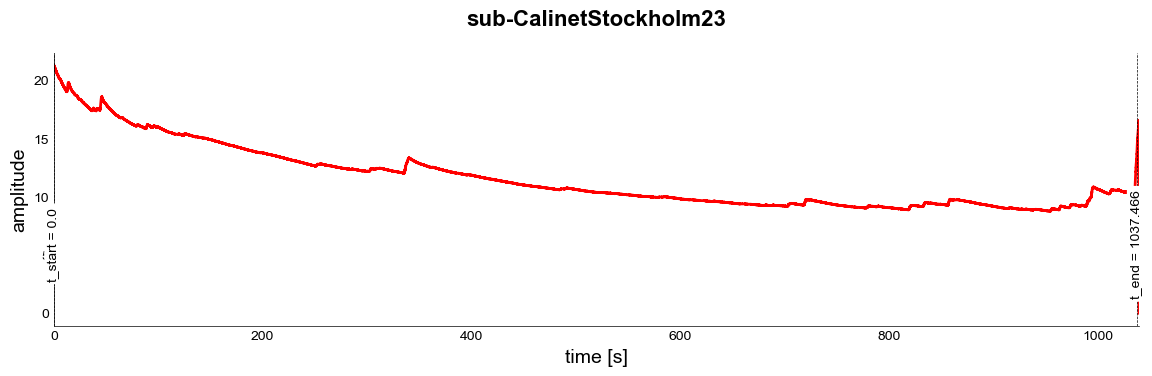

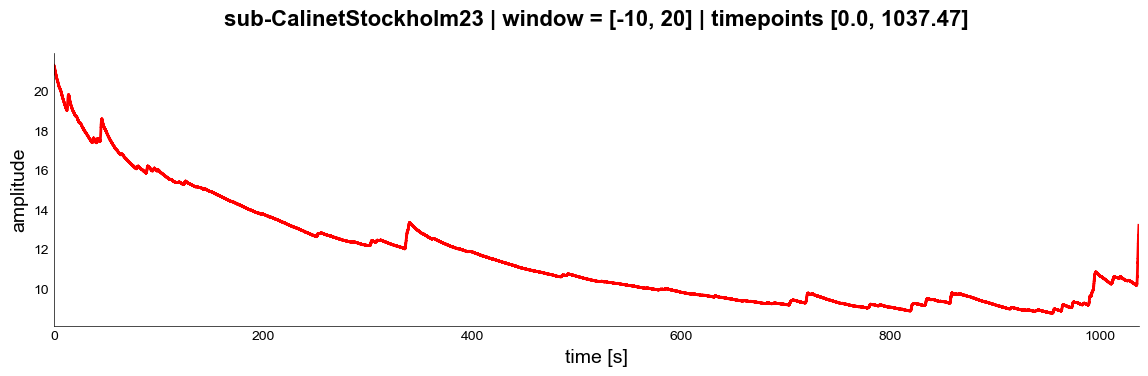

In [118]:
trim_res = pspm_trim(
    physio_df,
    events_df,
    from_=trim_window[0],
    to=trim_window[1],
    start_time=0,
    fs=sr
)

use_data = physio_df.copy()

pl = plotting.LazyLine(
    use_data['scr'].to_numpy(),
    xx=np.arange(0, use_data.shape[0])/sr,
    line_width=2,
    color="r",
    fontname="Arial",
    figsize=(14, 3.54),
    x_label="time [s]",
    y_label="amplitude",
    labels='SCR',
    add_vline={
        "pos": list(trim_res.trimpoints),
        "add_label": [
            {
                "lbl": f"t_start = {round(trim_res.trimpoints[0], 3)}",
                "l_max": 0.3
            },
            {
                "lbl": f"t_end = {round(trim_res.trimpoints[1], 3)}",
                "l_max": 0.3
            }            
        ]
    },
    title={
        "title": sub_id,
        "fontweight": "bold"
    }
)

use_data = trim_res.data.copy()
pl = plotting.LazyLine(
    use_data['scr'].to_numpy(),
    xx=np.arange(0, use_data.shape[0])/sr,
    line_width=2,
    color="r",
    fontname="Arial",
    figsize=(14, 3.54),
    x_label="time [s]",
    y_label="amplitude",
    labels='SCR',
    title={
        "title": f"{sub_id} | window = {trim_window} | timepoints {[round(i, 2) for i in trim_res.trimpoints]}",
        "fontweight": "bold"
    }
)

In [ ]:
# apply
results = run_pspm_trim_directory(
    root_dir=sub_path,
    from_=trim_window[0],
    to=trim_window[1],
    reference='marker',
    overwrite=True,
    filters=[f"task-{task}"]
)

ok = [r for r in results if r.get("status") == "ok"]
skipped = [r for r in results if r.get("status") == "skipped"]
errors = [r for r in results if r.get("status") == "error"]

logger.info(
    "Trim complete: %d ok | %d skipped | %d errors",
    len(ok),
    len(skipped),
    len(errors),
)

[2026-04-21 12:40:03.759] [sub-CalinetStockholm05] [INFO] calinet.data - Scanning directory for physio files: Z:\CALINET2\converted\Stockholm\sub-CalinetStockholm23\physio
[2026-04-21 12:40:03.768] [sub-CalinetStockholm05] [INFO] calinet.data - Applying physio filename filters: ['task-extinction']
[2026-04-21 12:40:03.775] [sub-CalinetStockholm05] [INFO] calinet.data - Found 3 physio file(s)
[2026-04-21 12:40:03.775] [sub-CalinetStockholm05] [INFO] calinet.data - Processing physio file: Z:\CALINET2\converted\Stockholm\sub-CalinetStockholm23\physio\sub-CalinetStockholm23_task-extinction_recording-eye1_physio.tsv.gz
[2026-04-21 12:40:04.135] [sub-CalinetStockholm05] [INFO] calinet.data - Starting PsPM-style trimming
[2026-04-21 12:40:04.141] [sub-CalinetStockholm05] [INFO] calinet.data - Trimming parameters: from=-10, to=20, reference=marker
[2026-04-21 12:40:04.148] [sub-CalinetStockholm05] [INFO] calinet.data - StartTime=0.000s, subtracting this from onset times to align channels
[2026

In [ ]:
# regenerate plot
qa_dir = base_path / site / 'derivatives' / 'qa'
finished_subject, fname = _generate_single_qa_plot(
    dataset_name=site,
    subject=sub_id,
    qa_dir=qa_dir,
)

logger.info("QA plot regenerated for %s", finished_subject)
logger.info("QA plot path: %s", fname)

[2026-04-21 12:36:29.764] [sub-CalinetStockholm05] [INFO] calinet.plotting - Read SamplingFrequency from Z:\CALINET2\converted\Stockholm\sub-CalinetStockholm05\physio\sub-CalinetStockholm05_task-acquisition_recording-eye1_physio.json
[2026-04-21 12:36:29.813] [sub-CalinetStockholm05] [INFO] calinet.plotting - SamplingFrequency=250
[2026-04-21 12:36:29.815] [sub-CalinetStockholm05] [INFO] calinet.plotting - Units for 'eye1'=mm
[2026-04-21 12:36:29.818] [sub-CalinetStockholm05] [INFO] calinet.plotting - Read 'eye1'/'acquisition' file: Z:\CALINET2\converted\Stockholm\sub-CalinetStockholm05\physio\sub-CalinetStockholm05_task-acquisition_recording-eye1_physio.tsv.gz
[2026-04-21 12:36:30.078] [sub-CalinetStockholm05] [INFO] calinet.plotting - 'eye1' channel index: -1
[2026-04-21 12:36:30.098] [sub-CalinetStockholm05] [INFO] calinet.plotting - Add events
[2026-04-21 12:36:30.134] [sub-CalinetStockholm05] [INFO] calinet.plotting - Read SamplingFrequency from Z:\CALINET2\converted\Stockholm\sub

In [106]:
import os
os.startfile(fname)

In [29]:
# from PIL import Image
# from IPython.display import display

# img = Image.open(fname)
# display(img)